# 06 — Counter-Assay pEC50 as a Feature

2,858 of 4,153 training compounds also appear in the PXR-null counter-assay,
giving a directly measured `pec50_null`. Adding it as a feature tells the model
whether a compound is a *selective* PXR activator (high PXR, low null) vs a
promiscuous transactivator.

**Strategy**
1. For training compounds with counter-assay data: use actual `pec50_null`.
2. For remaining train + all test: train a *null predictor* (LGBM on combined FP).
3. Retrain main LGBM with the extra column; measure scaffold-CV improvement.
4. Save `submissions/06_counter_lgbm.csv`.

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

from pxr.paths import DATA_PROCESSED, SUBMISSIONS, FIGURES
from pxr.data import load_train, load_test, load_counter
from pxr.featurize import combined, impute
from pxr.eval import scaffold_kfold_indices, compute_metrics

plt.rcParams.update({"figure.dpi": 120})
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── 2. Load data + inspect counter-assay overlap ──────────────────────────────
train_raw = load_train().dropna(subset=["pec50"])
cpd       = pd.read_parquet(DATA_PROCESSED / "compounds.parquet")
train = train_raw.merge(cpd[["name","std_smiles","scaffold"]], on="name", how="left")
train["smi"] = train["std_smiles"].fillna(train["smiles"])
train = train.reset_index(drop=True)

counter = load_counter().dropna(subset=["pec50"])
test    = load_test()

# Map actual null pEC50 onto training compounds
null_map = counter.set_index("name")["pec50"].to_dict()
train["pec50_null_actual"] = train["name"].map(null_map)

n_overlap = train["pec50_null_actual"].notna().sum()
print("Training compounds:      ", len(train))
print("Counter-assay compounds: ", len(counter))
print("Overlap (both datasets): ", n_overlap,
      f"({n_overlap/len(train):.1%} of train)")
null_vals = train["pec50_null_actual"].dropna()
print(f"pec50_null range: {null_vals.min():.2f} to {null_vals.max():.2f}")

# Spearman between pec50 and pec50_null
mask = train["pec50_null_actual"].notna()
r_spearman, _ = spearmanr(train.loc[mask, "pec50"],
                           train.loc[mask, "pec50_null_actual"])
print(f"Spearman(pec50, pec50_null): {r_spearman:.4f}")

Training compounds:       4153
Counter-assay compounds:  2647
Overlap (both datasets):  2661 (64.1% of train)
pec50_null range: 1.76 to 7.16
Spearman(pec50, pec50_null): -0.0271


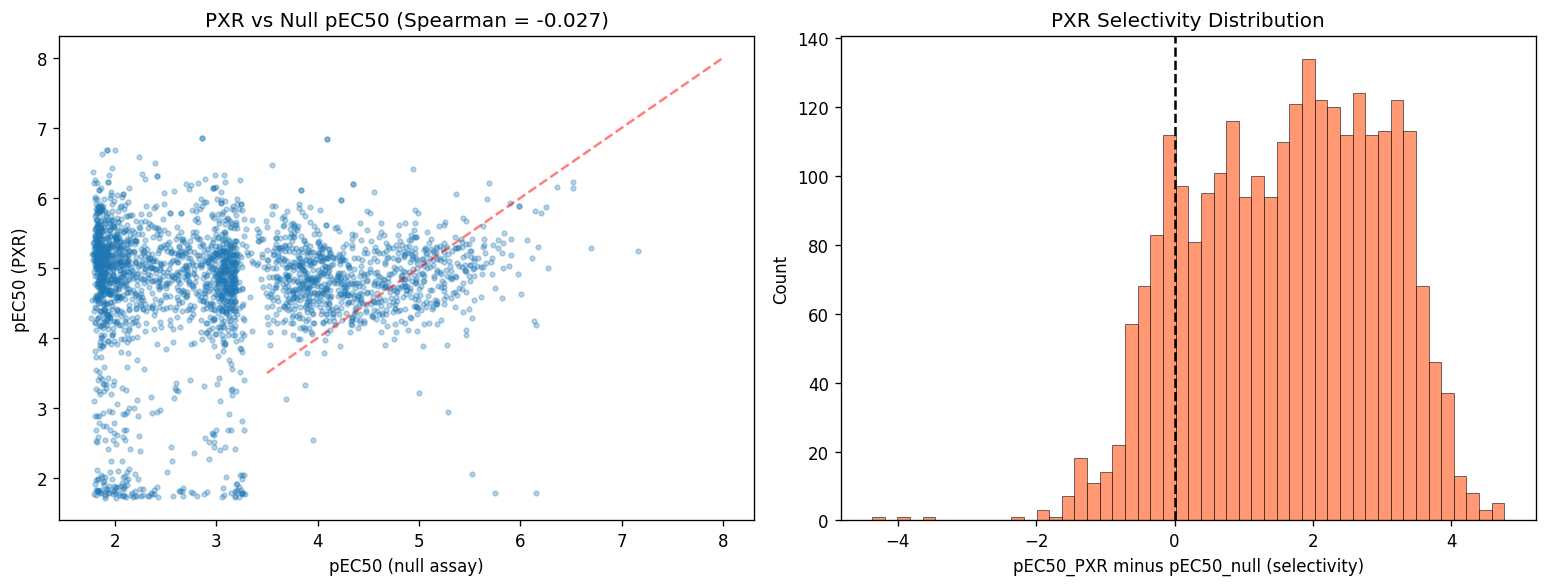

Saved 06_pxr_vs_null.png


In [3]:
# ── 3. Visualise pec50 vs pec50_null ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(train.loc[mask, "pec50_null_actual"], train.loc[mask, "pec50"],
           alpha=0.3, s=8)
lo, hi = 3.5, 8.0
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, alpha=0.5)
ax.set_xlabel("pEC50 (null assay)")
ax.set_ylabel("pEC50 (PXR)")
ax.set_title(f"PXR vs Null pEC50 (Spearman = {r_spearman:.3f})")

ax = axes[1]
selectivity = train.loc[mask, "pec50"] - train.loc[mask, "pec50_null_actual"]
ax.hist(selectivity, bins=50, color="coral", edgecolor="k", linewidth=0.4, alpha=0.8)
ax.axvline(0, color="k", linestyle="--", lw=1.5)
ax.set_xlabel("pEC50_PXR minus pEC50_null (selectivity)")
ax.set_ylabel("Count")
ax.set_title("PXR Selectivity Distribution")

plt.tight_layout()
plt.savefig(FIGURES / "06_pxr_vs_null.png", bbox_inches="tight")
plt.show()
print("Saved 06_pxr_vs_null.png")

In [4]:
# ── 4. Train null predictor (structure → pec50_null) ─────────────────────────
counter_smiles = counter["smiles"].tolist()
counter_y      = counter["pec50"].values

print("Computing features for null predictor...")
X_counter = impute(combined(counter_smiles))

null_params = dict(n_estimators=1000, learning_rate=0.05, num_leaves=64,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=4)
null_model = lgb.LGBMRegressor(**null_params)
null_model.fit(X_counter, counter_y)

null_in_sample = null_model.predict(X_counter)
print(f"Null predictor in-sample: R2={r2_score(counter_y, null_in_sample):.3f}  "
      f"Spearman={spearmanr(counter_y, null_in_sample).statistic:.3f}")
print("(In-sample numbers; actual generalisation measured by LOOCV on counter-assay)")

Computing features for null predictor...


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25141
[LightGBM] [Info] Number of data points in the train set: 2647, number of used features: 1408
[LightGBM] [Info] Start training from score 3.131044


Null predictor in-sample: R2=1.000  Spearman=1.000
(In-sample numbers; actual generalisation measured by LOOCV on counter-assay)


In [5]:
# ── 5. Build pec50_null feature for all compounds ─────────────────────────────
print("Computing features for training set...")
train_smiles = train["smi"].tolist()
X_train_base = impute(combined(train_smiles))
y_train      = train["pec50"].values

print("Computing features for test set...")
test_smiles = test["smiles"].tolist()
X_test_base = impute(combined(test_smiles))

# Predict pec50_null for all; override with actual where available
null_pred_train = null_model.predict(X_train_base)
null_pred_test  = null_model.predict(X_test_base)

pec50_null_train = null_pred_train.copy()
has_actual = train["pec50_null_actual"].notna()
pec50_null_train[has_actual] = train.loc[has_actual, "pec50_null_actual"].values

X_train_aug = np.hstack([X_train_base, pec50_null_train.reshape(-1, 1)])
X_test_aug  = np.hstack([X_test_base,  null_pred_test.reshape(-1, 1)])

print(f"Augmented feature dim: {X_train_aug.shape[1]} "
      f"({X_train_base.shape[1]} base + 1 null pEC50)")

Computing features for training set...


Computing features for test set...


Augmented feature dim: 2266 (2265 base + 1 null pEC50)


In [6]:
# ── 6. Scaffold CV — baseline vs augmented ────────────────────────────────────
scaffolds = train["scaffold"].tolist()
splits    = scaffold_kfold_indices(scaffolds, n_splits=5, seed=42)

lgbm_params = dict(n_estimators=1200, learning_rate=0.04, num_leaves=64,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=4)

rows = []
for label, X in [("baseline", X_train_base), ("+null_pec50", X_train_aug)]:
    for fold, (tr_idx, va_idx) in enumerate(splits):
        m = lgb.LGBMRegressor(**lgbm_params)
        m.fit(X[tr_idx], y_train[tr_idx])
        preds = m.predict(X[va_idx])
        metrics = compute_metrics(y_train[va_idx], preds)
        metrics["model"] = label
        metrics["fold"]  = fold
        rows.append(metrics)

cv_df = pd.DataFrame(rows)
summary = cv_df.groupby("model")[["RAE","MAE","R2","Spearman"]].mean().round(4)
print("Scaffold 5-fold CV — LGBM combined features:")
print(summary.to_string())

rae_base = summary.loc["baseline", "RAE"]
rae_aug  = summary.loc["+null_pec50", "RAE"]
print(f"\nRAE improvement: {rae_base:.4f} -> {rae_aug:.4f}  "
      f"(delta = {rae_aug - rae_base:+.4f})")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25643
[LightGBM] [Info] Number of data points in the train set: 3322, number of used features: 1589
[LightGBM] [Info] Start training from score 4.379262


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25569
[LightGBM] [Info] Number of data points in the train set: 3322, number of used features: 1551
[LightGBM] [Info] Start training from score 4.313978


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25576
[LightGBM] [Info] Number of data points in the train set: 3322, number of used features: 1547
[LightGBM] [Info] Start training from score 4.302161


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015023 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25583
[LightGBM] [Info] Number of data points in the train set: 3323, number of used features: 1555
[LightGBM] [Info] Start training from score 4.333694


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25562
[LightGBM] [Info] Number of data points in the train set: 3323, number of used features: 1551
[LightGBM] [Info] Start training from score 4.308249


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25824
[LightGBM] [Info] Number of data points in the train set: 3322, number of used features: 1552
[LightGBM] [Info] Start training from score 4.313978


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25831
[LightGBM] [Info] Number of data points in the train set: 3322, number of used features: 1548
[LightGBM] [Info] Start training from score 4.302161


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25838
[LightGBM] [Info] Number of data points in the train set: 3323, number of used features: 1556
[LightGBM] [Info] Start training from score 4.333694


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25817
[LightGBM] [Info] Number of data points in the train set: 3323, number of used features: 1552
[LightGBM] [Info] Start training from score 4.308249


Scaffold 5-fold CV — LGBM combined features:
                RAE     MAE      R2  Spearman
model                                        
+null_pec50  0.5637  0.5089  0.6070    0.7314
baseline     0.5675  0.5122  0.5964    0.7251

RAE improvement: 0.5675 -> 0.5637  (delta = -0.0038)


In [7]:
# ── 7. Train final model on all training data ─────────────────────────────────
final_model = lgb.LGBMRegressor(**lgbm_params)
final_model.fit(X_train_aug, y_train)
lgbm_aug_preds = final_model.predict(X_test_aug)

# Blend with Chemprop multitask (03)
chemprop_df   = pd.read_csv(SUBMISSIONS / "03_chemprop_multitask.csv")
chemprop_map  = dict(zip(chemprop_df["Molecule Name"], chemprop_df["pEC50"]))
chemprop_pred = np.array([chemprop_map[n] for n in test["name"]])

final_preds = 0.5 * lgbm_aug_preds + 0.5 * chemprop_pred
final_preds = np.clip(final_preds, y_train.min() - 0.5, y_train.max() + 0.5)

print(f"Augmented LGBM: {lgbm_aug_preds.min():.3f} to {lgbm_aug_preds.max():.3f}")
print(f"Blended:        {final_preds.min():.3f} to {final_preds.max():.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26428
[LightGBM] [Info] Number of data points in the train set: 4153, number of used features: 1765
[LightGBM] [Info] Start training from score 4.327468


Augmented LGBM: 2.313 to 6.022
Blended:        2.482 to 5.778


In [8]:
# ── 8. Save submission ────────────────────────────────────────────────────────
submission = pd.DataFrame({
    "Molecule Name": test["name"].values,
    "SMILES":        test["smiles"].values,
    "pEC50":         final_preds,
})
assert len(submission) == 513
assert submission["pEC50"].notna().all()

out_path = SUBMISSIONS / "06_counter_lgbm.csv"
submission.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(submission["pEC50"].describe().round(3))

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\06_counter_lgbm.csv
count    513.000
mean       4.793
std        0.576
min        2.482
25%        4.547
50%        4.923
75%        5.204
max        5.778
Name: pEC50, dtype: float64
